<a href="https://colab.research.google.com/github/faizaan0619/MachineLearning/blob/main/Supervised/LinearRegression_california_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseValue"] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print("Dataset Shape:", df.shape)
print("\nFeature Names:")
print(housing.feature_names)

Dataset Shape: (20640, 9)

Feature Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
print(df.isnull().sum())

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


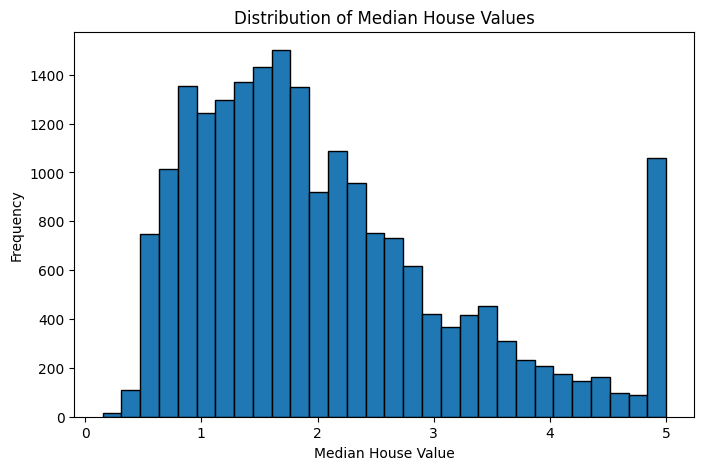

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(df["MedHouseValue"], bins=30, edgecolor="black")

plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

In [ ]:
correlation_matrix = df.corr()

print(correlation_matrix["MedHouseValue"].sort_values(ascending=False))

MedHouseValue    1.000000
MedInc           0.688075
AveRooms         0.151948
HouseAge         0.105623
AveOccup        -0.023737
Population      -0.024650
Longitude       -0.045967
AveBedrms       -0.046701
Latitude        -0.144160
Name: MedHouseValue, dtype: float64


In [ ]:
X = df.drop("MedHouseValue", axis=1)
y = df["MedHouseValue"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (16512, 8)
Testing feature shape: (4128, 8)
Training target shape: (16512,)
Testing target shape: (4128,)


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


In [ ]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.5332001304956565


In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.5558915986952442


In [ ]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 0.7455813830127763


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.575787706032451


In [ ]:
train_r2 = model.score(X_train_scaled, y_train)
test_r2 = model.score(X_test_scaled, y_test)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.6125511913966952
Testing R²: 0.575787706032451


In [ ]:
print("----- Model Performance -----")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

----- Model Performance -----
MAE  : 0.5332
MSE  : 0.5559
RMSE : 0.7456


In [ ]:
residuals = y_test - y_pred

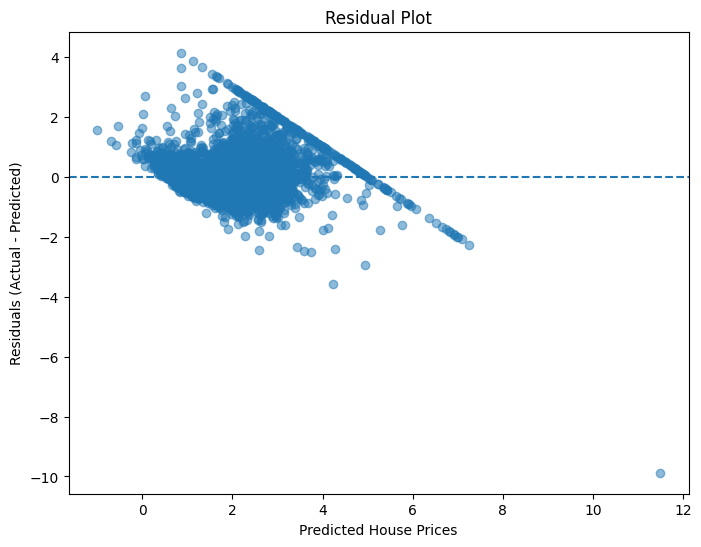

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals (Actual - Predicted)")

plt.show()

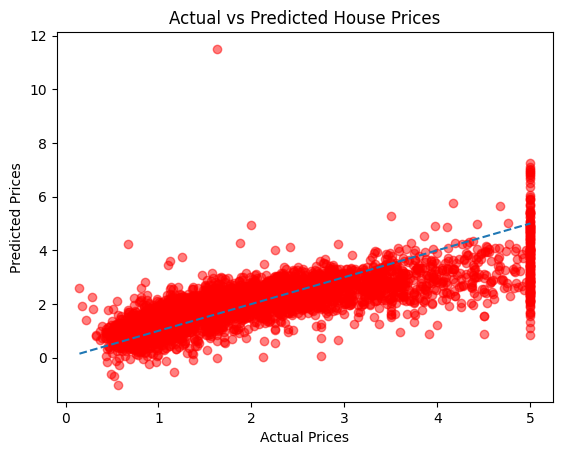

In [ ]:
plt.scatter(y_test, y_pred, color='red', alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [ ]:
from sklearn.linear_model import Ridge, Lasso

In [ ]:
from sklearn.preprocessing import StandardScaler

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)


ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MSE:", ridge_mse)
print("MAE:", ridge_mae)

Ridge Regression Results
MSE: 0.5558548589435971
MAE: 0.5331931195789733


In [ ]:
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("MSE:", lasso_mse)
print("MAE:", lasso_mae)

Lasso Regression Results
MSE: 0.6796290284328825
MAE: 0.6222011605619467


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MSE": [mse, ridge_mse, lasso_mse],
    "MAE": [mae, ridge_mae, lasso_mae]
})

print(results)

               Model       MSE       MAE
0  Linear Regression  0.555892  0.533200
1              Ridge  0.555855  0.533193
2              Lasso  0.679629  0.622201


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": model.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coefficients)

      Feature  Linear Regression     Ridge     Lasso
0      MedInc           0.854383  0.854327  0.710598
1    HouseAge           0.122546  0.122624  0.106453
2    AveRooms          -0.294410 -0.294210 -0.000000
3   AveBedrms           0.339259  0.339008  0.000000
4  Population          -0.002308 -0.002282 -0.000000
5    AveOccup          -0.040829 -0.040833 -0.000000
6    Latitude          -0.896929 -0.896168 -0.011469
7   Longitude          -0.869842 -0.869071 -0.000000


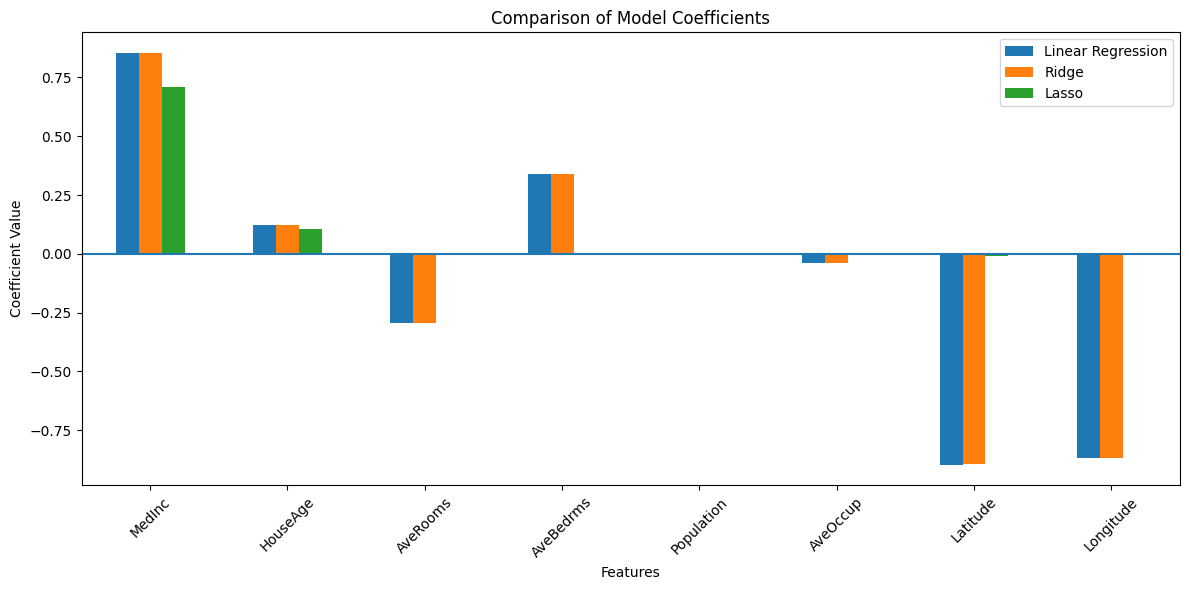

In [ ]:
coefficients.set_index("Feature").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Model Coefficients")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.axhline(y=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import SGDRegressor

In [ ]:
sgd_model = SGDRegressor(
    max_iter=5000,
    learning_rate="invscaling",
    eta0=0.001,
    random_state=42,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

y_pred_sgd = sgd_model.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred_sgd)
mae = mean_absolute_error(y_test, y_pred_sgd)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_sgd)

print("MSE :", mse)
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MSE : 0.5573700571079093
MAE : 0.5366909237052926
RMSE: 0.7465722048857092
R²  : 0.5746594640582164
